In [19]:
# Dealing with Outliers in Dataset


# definition:
# An outlier is a data point that significantly differs from other observations in a dataset.

# Different names of Outliers:
# Anomalies , Deviations , Exceptions , Aberrations , Noise , Contaminations , Noveltys

# Types of Outliers:
# 1. univariate Outliers
# 2. multivariate Outliers
# 3. Global Outliers
# 4. Contextual Outliers
# 5. Collective Outliers
# and many more...

In [ ]:
# Techniques to handle Outliers:
# 1. Z-Score Analysis(2nd No pa ya use hota ha) 
# 2. IQR Score Analysis (Market ma sub sa zyada use hota ha) 
# 3. K means Clustering

In [21]:
# Importing Libraries

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt


In [22]:
# 1. Z-Score Analysis ✅

# First we will create a sample dataset with outliers
data = {
    'Value': [10, 12, 12, 13, 12, 14, 13, 15, 14, 1000]  # 1000 is an outlier
}
df = pd.DataFrame(data)
df.head()   

,Value
0,10
1,12
2,12
3,13
4,12


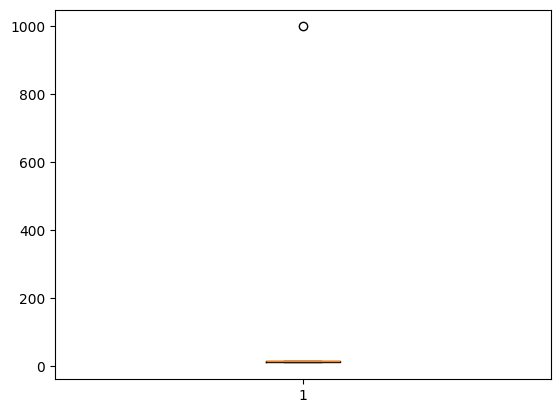

In [23]:
# 2 we draw boxplot to visualize outliers
plt.boxplot(df['Value'])
plt.show()

In [ ]:
# 3 Then we calculate mean and standard deviation
# formula for Z-Score: Z = (X - mean) / std

mean = np.mean(df['Value'])
std = np.std(df['Value'])


# 4 Now we calculate Z-Score for each data point    
df['Z-Score'] = (df['Value'] - mean) / std
df


,Value,Z-Score
0,10,-0.342709
1,12,-0.335956
2,12,-0.335956
3,13,-0.332580
4,12,-0.335956
5,14,-0.329203
6,13,-0.332580
7,15,-0.325827
8,14,-0.329203
9,1000,2.999970


In [25]:
# Removing Outliers based on Z-Score
threshold = 2.5 # Common threshold values are 2 or 3
data = df[df['Z-Score']<=threshold]
data

,Value,Z-Score
0,10,-0.342709
1,12,-0.335956
2,12,-0.335956
3,13,-0.332580
4,12,-0.335956
5,14,-0.329203
6,13,-0.332580
7,15,-0.325827
8,14,-0.329203


In [ ]:
# 2 IQR Score Analysis ✅ 

# Creating sample dataset with outliers
data = {
    'Value': [10, 12, 12, 13, 12, 14, 13, 15, 14, 1000]  # 1000 is an outlier
}
df = pd.DataFrame(data)
df.head()



,Value
0,10
1,12
2,12
3,13
4,12


In [30]:
# Techniques to handle Outliers:
# Formula for IQR: IQR = Q3 - Q1
Q1 = df['Value'].quantile(0.25)
Q3 = df['Value'].quantile(0.75)
IQR = Q3 - Q1 

# Defining lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
# Filtering out the outliers

data = df[(df['Value'] >= lower_bound) & (df['Value'] <= upper_bound)]
data

,Value
0,10
1,12
2,12
3,13
4,12
5,14
6,13
7,15
8,14


In [32]:
# 3 K means Clustering ✅
# Importing Libraries
from sklearn.cluster import KMeans


# sample dataset with outliers
data = {
    'Value': [10, 12, 12, 13, 12, 14, 13, 15, 14, 1000]  # 1000 is an outlier  
}
df = pd.DataFrame(data) 
df.head()    

,Value
0,10
1,12
2,12
3,13
4,12


In [33]:
# now we apply K means clustering
kmeans = KMeans(n_clusters=2)
kmeans.fit(df[['Value']])
df['Cluster'] = kmeans.labels_
df

,Value,Cluster
0,10,0
1,12,0
2,12,0
3,13,0
4,12,0
5,14,0
6,13,0
7,15,0
8,14,0
9,1000,1


In [34]:
# Removing Outliers based on Clustering
data = df[df['Cluster'] == df['Cluster'].mode()[0]]
data

,Value,Cluster
0,10,0
1,12,0
2,12,0
3,13,0
4,12,0
5,14,0
6,13,0
7,15,0
8,14,0
